In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [15]:
df = pd.read_csv("Eda fifa.csv")

In [16]:
df.head()

,Name,Team,Number,Position,Age,Height,Weight,College,Salary
0,Avery Bradley,Boston Celtics,0,PG,25,06-Feb,180,Texas,7730337.0
1,Jae Crowder,Boston Celtics,99,SF,25,06-Jun,235,Marquette,6796117.0
2,John Holland,Boston Celtics,30,SG,27,06-May,205,Boston University,NaN
3,R.J. Hunter,Boston Celtics,28,SG,22,06-May,185,Georgia State,1148640.0
4,Jonas Jerebko,Boston Celtics,8,PF,29,06-Oct,231,NaN,5000000.0


In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 458 entries, 0 to 457
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Name      458 non-null    object 
 1   Team      458 non-null    object 
 2   Number    458 non-null    int64  
 3   Position  458 non-null    object 
 4   Age       458 non-null    int64  
 5   Height    458 non-null    object 
 6   Weight    458 non-null    int64  
 7   College   374 non-null    object 
 8   Salary    447 non-null    float64
dtypes: float64(1), int64(3), object(5)
memory usage: 32.3+ KB


In [18]:
print(df.columns)

Index(['Name', 'Team', 'Number', 'Position', 'Age', 'Height', 'Weight',
       'College', 'Salary'],
      dtype='object')


In [9]:
df.columns = df.columns.str.strip()

In [19]:
df.isnull().sum()

Name         0
Team         0
Number       0
Position     0
Age          0
Height       0
Weight       0
College     84
Salary      11
dtype: int64

In [20]:
np.random.seed(10)

df["Height"] = np.random.randint(150,181,size=len(df))

df.head()

,Name,Team,Number,Position,Age,Height,Weight,College,Salary
0,Avery Bradley,Boston Celtics,0,PG,25,159,180,Texas,7730337.0
1,Jae Crowder,Boston Celtics,99,SF,25,179,235,Marquette,6796117.0
2,John Holland,Boston Celtics,30,SG,27,154,205,Boston University,NaN
3,R.J. Hunter,Boston Celtics,28,SG,22,165,185,Georgia State,1148640.0
4,Jonas Jerebko,Boston Celtics,8,PF,29,150,231,NaN,5000000.0


In [21]:
team_count = df["Team"].value_counts()

print(team_count)

Team
New Orleans Pelicans      19
Memphis Grizzlies         18
Utah Jazz                 16
Milwaukee Bucks           16
New York Knicks           16
Boston Celtics            15
Los Angeles Clippers      15
Los Angeles Lakers        15
Phoenix Suns              15
Sacramento Kings          15
Brooklyn Nets             15
Philadelphia 76ers        15
Toronto Raptors           15
Golden State Warriors     15
Indiana Pacers            15
Detroit Pistons           15
Cleveland Cavaliers       15
Chicago Bulls             15
Houston Rockets           15
San Antonio Spurs         15
Atlanta Hawks             15
Dallas Mavericks          15
Charlotte Hornets         15
Miami Heat                15
Denver Nuggets            15
Washington Wizards        15
Portland Trail Blazers    15
Oklahoma City Thunder     15
Orlando Magic             14
Minnesota Timberwolves    14
Name: count, dtype: int64


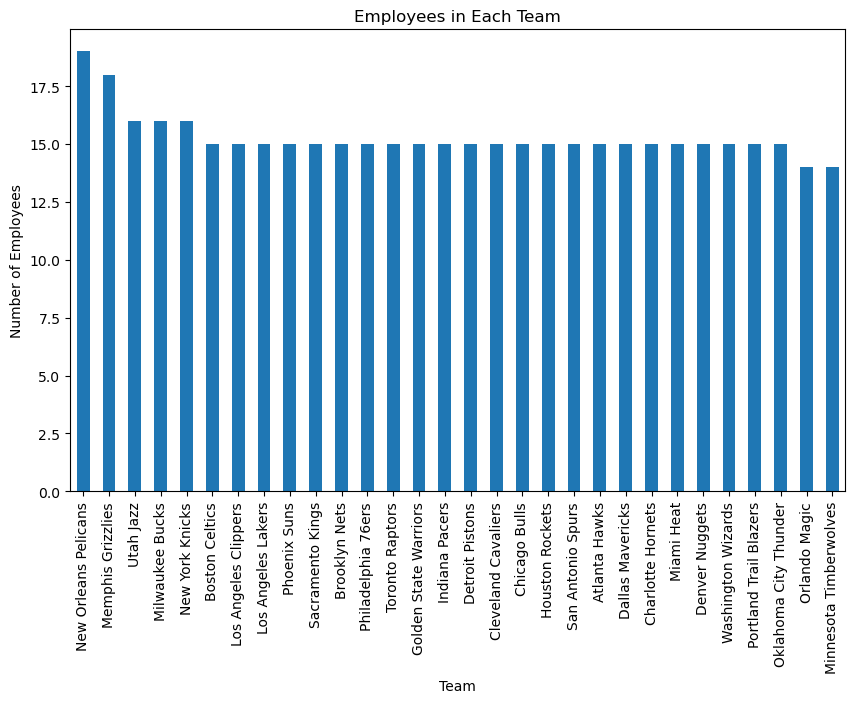

In [22]:
plt.figure(figsize=(10,6))
team_count.plot(kind="bar")

plt.title("Employees in Each Team")
plt.xlabel("Team")
plt.ylabel("Number of Employees")
plt.show()

In [23]:
position_count = df["Position"].value_counts()

print(position_count)

Position
SG    102
PF    100
PG     92
SF     85
C      79
Name: count, dtype: int64


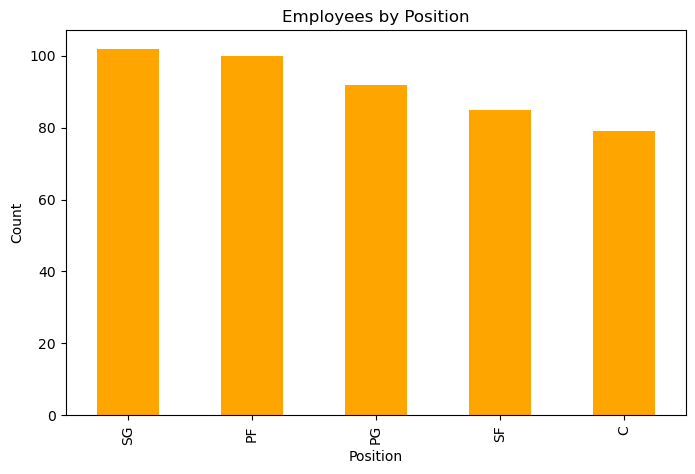

In [24]:
plt.figure(figsize=(8,5))
position_count.plot(kind="bar",color="orange")

plt.title("Employees by Position")
plt.xlabel("Position")
plt.ylabel("Count")
plt.show()

In [25]:
bins=[20,25,30,35,40,45,50]

labels=["20-25","26-30","31-35","36-40","41-45","46-50"]

df["Age Group"]=pd.cut(df["Age"],bins=bins,labels=labels)

In [26]:
age_group=df["Age Group"].value_counts()

print(age_group)

Age Group
20-25    179
26-30    167
31-35     68
36-40     23
41-45      0
46-50      0
Name: count, dtype: int64


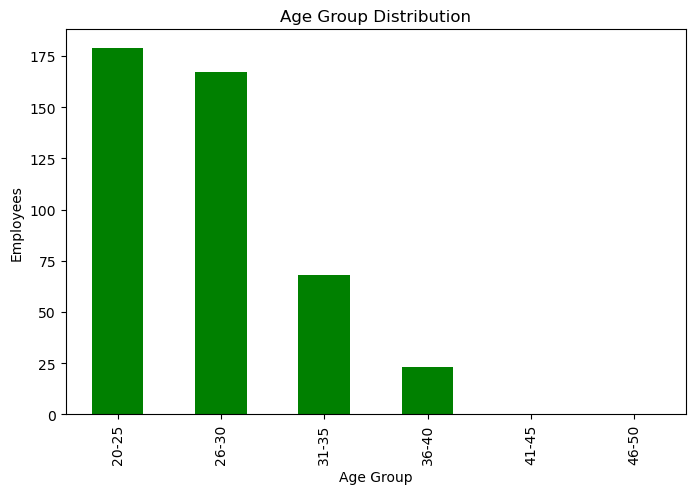

In [27]:
plt.figure(figsize=(8,5))
age_group.plot(kind="bar",color="green")

plt.title("Age Group Distribution")
plt.xlabel("Age Group")
plt.ylabel("Employees")
plt.show()

In [28]:
team_salary=df.groupby("Team")["Salary"].sum()

print(team_salary)

Team
Atlanta Hawks              72902950.0
Boston Celtics             58541068.0
Brooklyn Nets              52528475.0
Charlotte Hornets          78340920.0
Chicago Bulls              86783378.0
Cleveland Cavaliers       106988689.0
Dallas Mavericks           71198732.0
Denver Nuggets             60121930.0
Detroit Pistons            67168263.0
Golden State Warriors      88868997.0
Houston Rockets            75283021.0
Indiana Pacers             66751826.0
Los Angeles Clippers       94854640.0
Los Angeles Lakers         71770431.0
Memphis Grizzlies          76550880.0
Miami Heat                 82515673.0
Milwaukee Bucks            69603517.0
Minnesota Timberwolves     59709697.0
New Orleans Pelicans       82750774.0
New York Knicks            73303898.0
Oklahoma City Thunder      93765298.0
Orlando Magic              60161470.0
Philadelphia 76ers         30992894.0
Phoenix Suns               63445135.0
Portland Trail Blazers     48301818.0
Sacramento Kings           71683666.0
San Ant

In [29]:
print(team_salary.idxmax())

Cleveland Cavaliers


In [30]:
position_salary=df.groupby("Position")["Salary"].sum()

print(position_salary)

Position
C     466377332.0
PF    442560850.0
PG    446848971.0
SF    408020976.0
SG    396976258.0
Name: Salary, dtype: float64


In [31]:
print(position_salary.idxmax())

C


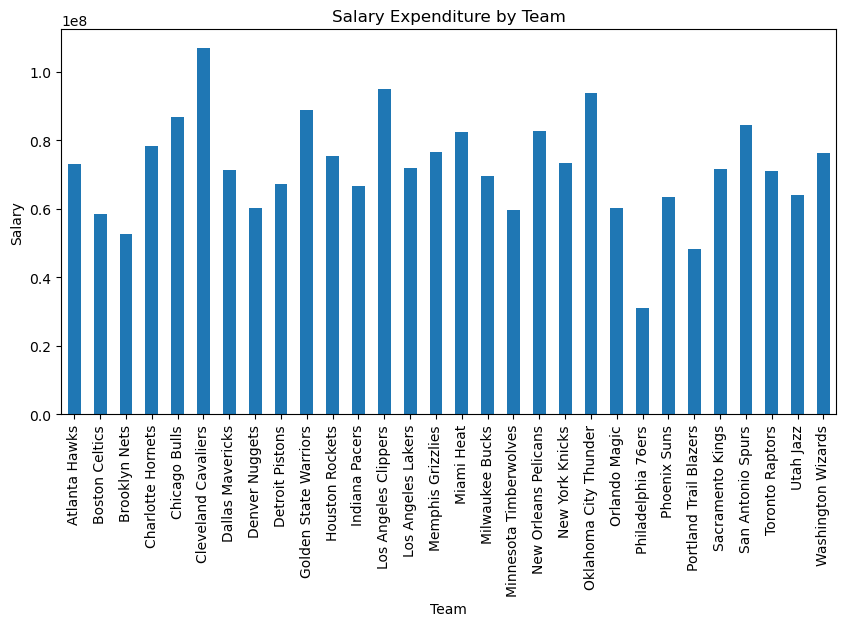

In [32]:
plt.figure(figsize=(10,5))
team_salary.plot(kind="bar")

plt.title("Salary Expenditure by Team")
plt.xlabel("Team")
plt.ylabel("Salary")
plt.show()

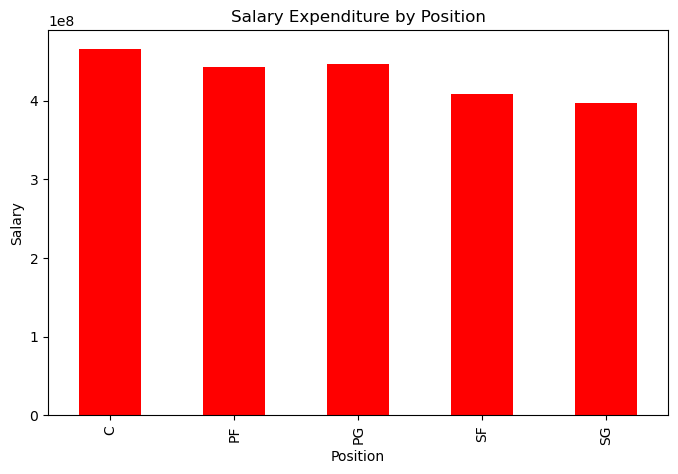

In [33]:
plt.figure(figsize=(8,5))
position_salary.plot(kind="bar",color="red")

plt.title("Salary Expenditure by Position")
plt.xlabel("Position")
plt.ylabel("Salary")
plt.show()

In [34]:
correlation=df["Age"].corr(df["Salary"])

print(correlation)

0.21400941226570985


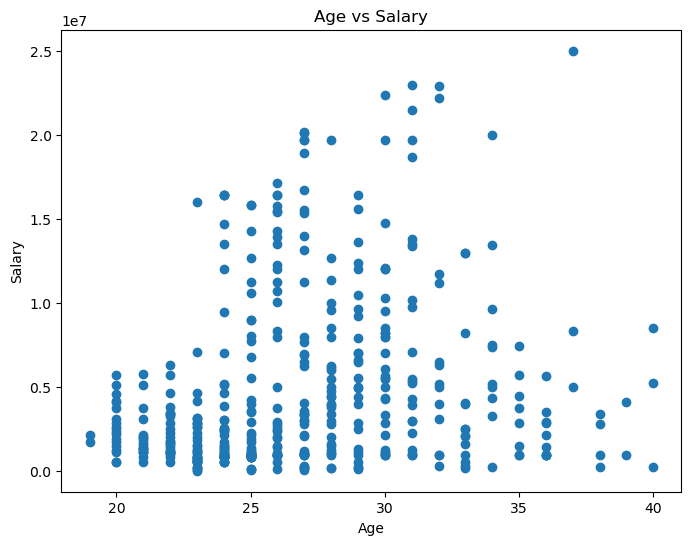

In [35]:
plt.figure(figsize=(8,6))

plt.scatter(df["Age"],df["Salary"])

plt.title("Age vs Salary")

plt.xlabel("Age")

plt.ylabel("Salary")

plt.show()